In [1]:
from maskvar.datasets.coco_lvis import LvisDataset
from maskvar.datasets.hqseg44k import HQSeg44KTrainDataset, HQSeg44KTestDataset
from maskvar.datasets.mask_level_dataset import MaskLevelDatasetRandom
from maskvar.datasets import instance_info

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from itertools import islice

from torchvision.utils import make_grid

In [2]:
# datasets = LvisDataset(
#     dataset_path='data/coco_lvis',
#     split='val',
#     img_split='val',
#     stuff_prob=0.0,
# )
dataset = HQSeg44KTrainDataset(
    data_root='../data/sam-hq',
    img_size=(512, 512)
)

In [3]:
def visualize_mask(image, layers, instances_info, alpha=0.5):
    plt.imshow(image // 2)
    for l in range(layers.shape[-1]):
        masked_data = np.ma.masked_where(layers[:, :, l] == 0, layers[:, :, l])
        plt.imshow(masked_data, alpha=alpha, cmap='tab20c')
    plt.show()

In [4]:
data_iter = iter(dataset)

(512, 512, 3)
(512, 512, 1)
{0: InstanceInfo(mapping=(0, 1), parent=None, children=[], node_level=0)}


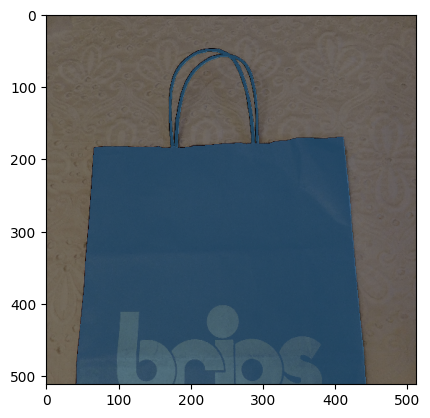

In [5]:
image, layers, instances_info = next(data_iter)

print(image.shape)
print(layers.shape)
print(instances_info)
visualize_mask(image, layers, instances_info, alpha=0.5)


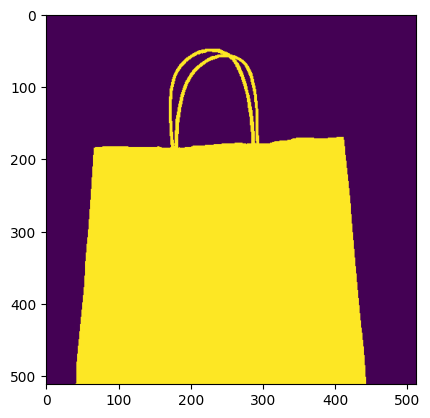

In [6]:
mask = layers[:, :, instances_info[0].mapping[0]]
plt.imshow(mask==instances_info[0].mapping[1])